# Семинар 8: Краткое введение в `torch.autograd`


## Тензоры

Тензоры — это специализированная структура данных, очень похожая на массивы и матрицы. В `PyTorch` мы используем тензоры для кодирования входных и выходных данных модели, а также ее параметров.

Тензоры похожи на массивы `NumPy`, за исключением того, что тензоры могут работать на графических процессорах или другом специализированном оборудовании для ускорения вычислений. Если вы знакомы с массивами NumPy, то без труда освоите Tensor API.

In [103]:
import torch
import numpy as np

### Инициализация тензоров
Тензоры можно инициализировать разными способами. Рассмотрим следующие примеры:



#### Непосредственно из данных

Тензоры можно создавать непосредственно из данных. Тип данных определяется автоматически.

In [104]:
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)

#### Из массива `NumPy`
Тензоры можно создавать из массивов `NumPy` (и наоборот — см. [Bridge with NumPy](https://docs.pytorch.org/tutorials/beginner/blitz/tensor_tutorial.html#bridge-to-np-label)).

In [105]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

#### Из другого тензора

Новый тензор сохраняет свойства (форму, тип данных) исходного тензора, если они не были явно переопределены.

In [106]:
x_ones = torch.ones_like(x_data) # сохраняет свойства x_data
print(f"Тензор единиц: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # переопределяет тип данных x_data
print(f"Случайный тензор: \n {x_rand} \n")

Тензор единиц: 
 tensor([[1, 1],
        [1, 1]]) 

Случайный тензор: 
 tensor([[0.6226, 0.7766],
        [0.4842, 0.2091]]) 



#### Со случайными или постоянными значениями

`shape` — это кортеж размерностей тензора. В приведенных ниже функциях он определяет размерность выходного тензора.

In [107]:
shape = (2, 3,)
random_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Случайный тензор: \n {random_tensor} \n")
print(f"Тензор единиц: \n {ones_tensor} \n")
print(f"Тензор нулей: \n {zeros_tensor}")

Случайный тензор: 
 tensor([[0.9576, 0.2923, 0.8790],
        [0.6002, 0.3823, 0.8677]]) 

Тензор единиц: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Тензор нулей: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Атрибуты тензора

Атрибуты тензора описывают его форму, тип данных и устройство, на котором он хранится.

In [108]:
tensor = torch.rand(3, 4)

print(f"Форма тензора: {tensor.shape}")
print(f"Тип данных тензора: {tensor.dtype}")
print(f"Тензор хранится на устройстве: {tensor.device}")

Форма тензора: torch.Size([3, 4])
Тип данных тензора: torch.float32
Тензор хранится на устройстве: cpu


### Тензорные операции

Более 100 тензорных операций, включая транспонирование, индексирование, нарезку, математические операции, линейную алгебру, случайную выборку и многое другое, подробно описаны [здесь](https://docs.pytorch.org/docs/stable/torch.html).

Каждый из них может быть запущен на графическом процессоре (GPU) (обычно на более высоких скоростях, чем на центральном процессоре (CPU)). Если вы работаете в Colab, вы можете сменить устройство в настройках.

В этом ноутбуке вы получите общее представление о том как работать в `torch`, как автоградиент помогает обучать нейронные сети и обучите свою первую НС.

In [109]:
# Если доступна CUDA, мы перемещаем наш тензор на графический процессор
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Тензор устройства хранится на: {tensor.device}")

Тензор устройства хранится на: cuda:0


#### Индексация и Slices



In [110]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


#### Объединение тензоров

С помощью `torch.cat` можно объединить последовательность тензоров по заданному измерению. 

In [111]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


#### Умножение тензоров

In [112]:
# Вычисляет поэлементное произведение
print(f"tensor.mul(tensor) \n {tensor.mul(tensor)} \n")
# Альтернативный синтаксис:
print(f"tensor * tensor \n {tensor * tensor}")

tensor.mul(tensor) 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor * tensor 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [113]:
print(f"tensor.matmul(tensor.T) \n {tensor.matmul(tensor.T)} \n")
# Альтернативный синтаксис:
print(f"tensor @ tensor.T \n {tensor @ tensor.T}")

tensor.matmul(tensor.T) 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]]) 

tensor @ tensor.T 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


#### inplace операции

Операции с суффиксом `_` выполняются на месте.
Например, `x.t_()`, изменит `x`.


In [114]:
print(tensor, "\n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


> Операции на месте позволяют сэкономить немного памяти, но могут вызвать проблемы при вычислении производных из-за мгновенной потери истории вычислений. Поэтому их использование не рекомендуется

### Bridge с NumPy

Тензоры на центральном процессоре и массивы NumPy могут использовать одни и те же области памяти, и изменение одного из них приведет к изменению другого.

#### Преобразование тензора в массив NumPy


In [115]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


Изменение тензора отражается на массиве NumPy.

In [116]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


#### Преобразование массива NumPy в Tensor

In [117]:
n = np.ones(5)
t = torch.from_numpy(n)

Изменения в массиве NumPy отражаются в тензоре.

In [118]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


`torch.autograd` Это механизм автоматического дифференцирования PyTorch, который обеспечивает обучение нейронных сетей. 

## Предыстория


Нейронные сети (НС) представляют собой набор вложенных функций, которые применяются к некоторым входным данным. Эти функции определяются параметрами (состоящими из весовых коэффициентов и смещений), которые в PyTorch хранятся в виде тензоров.

Обучение нейронной сети происходит в два этапа:

**Прямое распространение** (`forward`): при прямом распространении нейронная сеть делает наилучшее предположение о правильном результате. Для этого она пропускает входные данные через каждую из своих функций.

**Обратное распространение** (`backward`): при обратном распространении нейронная сеть корректирует свои параметры в соответствии с ошибкой (loss) в своих предположениях. Для этого она движется в обратном направлении от результата, собирает производные ошибки по параметрам функций (градиенты) и оптимизирует параметры с помощью градиентного спуска. Более подробное описание обратного распространения можно найти в этом видео от [3Blue1Brown](https://vk.com/video-91031095_456245011)

## Использование PyTorch

Давайте рассмотрим один этап обучения. В этом примере мы загружаем предварительно обученную модель [resnet18](https://huggingface.co/qualcomm/ResNet18) из torchvision. Мы создаем случайный тензор данных для представления одного изображения с 3 каналами, высотой и шириной 64, и соответствующим `label` инициализируем его случайными значениями. В предварительно обученных моделях метка имеет форму (1,1000).

![alt](../data/15.webp)

> Все коды в этом ноутбуке предназначены только для центрального процессора и не будут работать на графических процессорах (даже если тензоры будут перенесены в CUDA).

In [119]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

Затем мы пропускаем входные данные через модель, проходящие через каждый из ее слоев, чтобы получить прогноз. Это **прямой проход** (`forward`).

In [120]:
prediction = model(data) # forward pass

Мы используем прогноз модели и соответствующую метку для вычисления ошибки (loss). Следующий шаг — обратное распространение ошибки по сети. Обратное распространение запускается, когда мы вызываем `.backward()` для тензора ошибок. Затем автоградиент вычисляет и сохраняет градиенты для каждого параметра модели в атрибуте `.grad` этого параметра.

In [121]:
loss = (prediction - labels).sum()
loss.backward() # обратный проход

Затем мы загружаем оптимизатор, в данном случае SGD, со скоростью обучения (`learning rate`) $0.01$ и инерцией (`momentum`) $0.9$. Мы регистрируем все параметры модели в оптимизаторе.

In [122]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Наконец, мы вызываем `.step()` для запуска градиентного спуска. Оптимизатор корректирует каждый параметр в соответствии с его градиентом, хранящимся в `.grad`.

In [123]:
optim.step() # градиентный спуск

Теперь у вас есть все необходимое для обучения нейронной сети.

### Дифференциация в Autograd

Давайте посмотрим, как autograd собирает градиенты. Мы создаем два тензора $a$ и $b$ с помощью `requires_grad=True`. Это сигнализирует **autograd** о том, что каждая операция с ними должна отслеживаться.

In [124]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

Мы создаем еще один тензор $Q$ из $a$ и $b$.

$$Q = 3a^3 -b^2$$

In [125]:
Q = 3*a**3 - b**2

Предположим, что $a$ и $b$ — это параметры нейронной сети, а $Q$ — ошибка. При обучении нейронной сети нам нужны градиенты ошибки по отношению к параметрам, то есть

$$ \frac{\partial Q}{\partial a} = 9a^2$$

$$ \frac{\partial Q}{\partial b} = -2b$$

Когда мы вызываем `.backward()` для $Q$, **autograd** вычисляет эти градиенты и сохраняет их в атрибуте `.grad` соответствующих тензоров.

Нам нужно явно указать аргумент `gradient` в `Q.backward()`, потому что Q — это тензор. `gradient` — это тензор той же формы, что и `Q`, представляющий собой градиент функции `Q` по самой себе, то есть

$$ \frac{d Q}{d Q} = 1$$

Аналогичным образом мы можем объединить $Q$ в скаляр и неявно вызвать функцию в обратном порядке, как `Q.sum().backward()`.

In [126]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

Градиенты теперь сохраняются в `a.grad` и `b.grad`

In [127]:
# проверяем правильность собранных градиентов
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


### Вычислительный граф

По сути, автоградиент сохраняет данные (тензоры) и все выполненные операции (вместе с полученными новыми тензорами) в виде ориентированного ациклического графа (DAG), состоящего из объектов `Function`. В этом DAG листья — это входные тензоры, а корни — выходные. Прослеживая этот граф от корней к листьям, можно автоматически вычислить градиенты с помощью цепного правила.

При прямом проходе автоградиент выполняет две задачи одновременно:

* запустите запрошенную операцию для вычисления результирующего тензора и

* сохраните функцию градиента операции в DAG.

Обратный проход запускается при вызове `.backward()` в корневом узле DAG. autograd затем:

* вычисляет градиенты для каждого `.grad_fn`,

* накапливает их в атрибуте `.grad` соответствующего тензора и

* с помощью правила цепного дифференцирования распространяет их до конечных тензоров.

Ниже представлено визуальное представление ациклического графа в нашем примере. На графике стрелки указывают направление прямого прохода. Узлы представляют обратные функции для каждой операции прямого прохода. Конечные узлы синего цвета представляют наши конечные тензоры `a` и `b`.

![alt](../data/15.png)

> **В PyTorch динамические ациклические графы** Важно отметить, что граф создается с нуля; после каждого `.backward()` вызова автоградиент начинает заполнять новый граф. Именно это позволяет использовать в модели операторы управления потоком. При необходимости вы можете менять форму, размер и операции на каждой итерации.

## Создание NN на torch



Зададим датасет для бинарной классификации точек на плоскости:

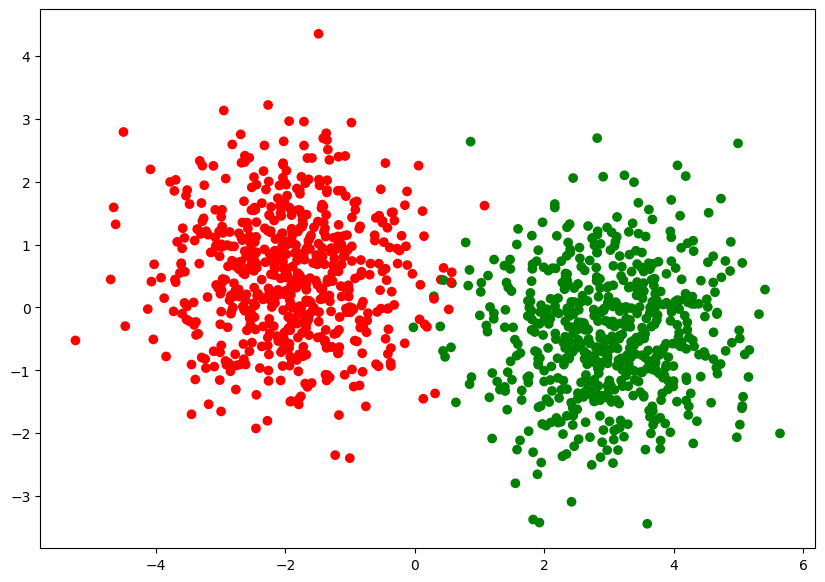

In [128]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# генерируем 1200 точек, распределенных вокруг двух центров: (-2,0.5) и (3,-0.5)
X, y = make_blobs(n_samples=1200, centers=[[-2,0.5],[3,-0.5]], cluster_std=1, random_state=42)

# отрисовываем точки на плоскости, покрасив их в два цвета в зависимости от класса
colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10,7))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.show()

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=200)

Давайте зададим нейронную сеть с двумя слоями для решения задачи бинарной классификации. Пусть в скрытых слоях будет пять нейронов. В качестве функции активации выберем сигмоиду.

Нейросеть задается в виде класса, который наследуется от абстрактного класса Module. Для задания нейросети достаточно определить у класса методы `__init__` и `__forward__`. В методе `__init__` обычно прописываются слои и артибуты сети, а в `__forward__` — то, как нейросеть будет обрабатывать данные, поданные ей на вход.

In [130]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Sigmoid() # можно заменить на nn.Tanh / nn.ReLU / ...

        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()


    def forward(self, x):
        """
        params:
            x (torch.Tensor): данные, поданные на вход сети
        """

        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)
        return x

Заведем нейросеть:

In [131]:
model = Net()

Посмотрим, что умеет наша необученная нейросеть. Получим ее ответы на тестовой выборке и визуализируем, к какому классу наша нейросеть отнесла какие точки тестовой выборки.

In [132]:
nn_prediction = model(torch.FloatTensor(X_test))

nn_prediction = nn_prediction.tolist()

In [133]:
nn_prediction

[[0.6740543842315674],
 [0.6486255526542664],
 [0.5747126936912537],
 [0.6758009791374207],
 [0.6919403076171875],
 [0.659286379814148],
 [0.6723860502243042],
 [0.64557284116745],
 [0.6634806990623474],
 [0.6679156422615051],
 [0.6133627891540527],
 [0.6669582724571228],
 [0.6273967027664185],
 [0.6842057108879089],
 [0.6699097752571106],
 [0.6639904379844666],
 [0.6306982040405273],
 [0.6787868142127991],
 [0.6727710366249084],
 [0.6660664677619934],
 [0.6357855796813965],
 [0.6264210343360901],
 [0.6283407211303711],
 [0.6346702575683594],
 [0.6398212909698486],
 [0.6145764589309692],
 [0.6824252009391785],
 [0.6888885498046875],
 [0.6120639443397522],
 [0.6685187816619873],
 [0.6194286942481995],
 [0.679233193397522],
 [0.6589202284812927],
 [0.6690161824226379],
 [0.6663103103637695],
 [0.6762189865112305],
 [0.6603482365608215],
 [0.6555113792419434],
 [0.6467846632003784],
 [0.6795510649681091],
 [0.6011937856674194],
 [0.6777234077453613],
 [0.6620435118675232],
 [0.63390767574

Переведем предсказания сети из вероятностей в формат нулей и единиц:

In [134]:
nn_prediction = np.array([int(x[0] > 0.5) for x in nn_prediction])

In [135]:
nn_prediction

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

Визуализируем точки тестовой выборки и покрасим их в цвета в зависимости от того, к какому классу сеть отнесла эти точки:

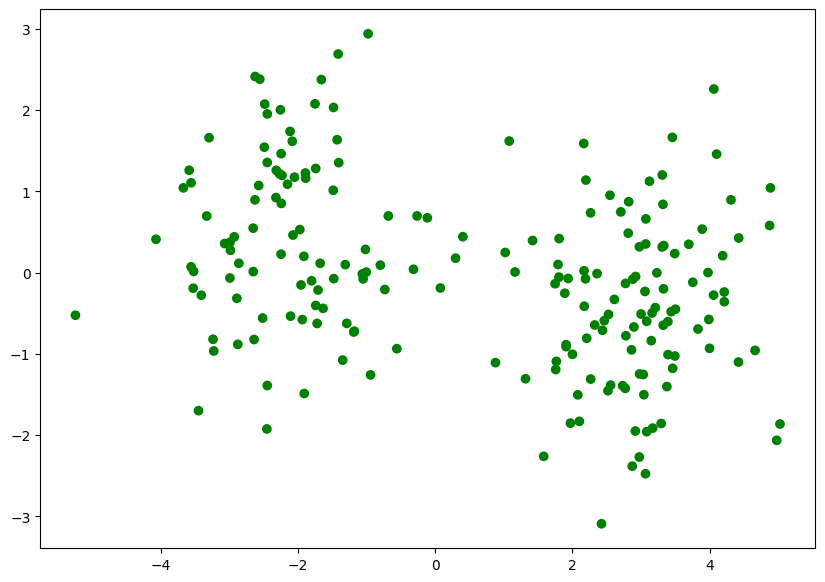

In [136]:
colors = ("red", "green")
colored_y = np.zeros(len(nn_prediction), dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[nn_prediction.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10,7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y)
plt.show()

Полученный результат ожидаем, поскольку наша нейронная сеть не обучена. Давайте обучим её.

#### Обучение нейронной сети в Pytorch

При написании класса сети в PyTorch нам ну нужно самостоятельно реализовывать вычисление производных и код обновления весов. Внутри PyTorch алгоритм вычисления частных производных лосс-функции по весам сети реализован с помощью модуля [autograd](https://pytorch.org/tutorials/beginner/blitz/autograd_tutorial.html). На основе строения функции сети, заданной в forward, autograd понимает, как выглядит граф вычислений сети, и при вызове метода backward у последнего элемента графа (лосс-функции), проходит по графу в обратном направлении, вычисляя все градиенты.



А мы перейдем к написанию функции `train` для обучения нашей нейронной сети.

**В обучении сети участвуют следующие сущности:**
- сама нейросеть
- лосс-функция
- оптимизатор (optimizer)

**Что такое оптимизатор:**

Оптимизатор — это сущность, которая отвечает за обновление параметров сети на основе их текущих значений и значений их производных.

Итак, теперь мы готовы реализовать функцию обучения сети. Реализуем для начала обычный градиентный спуск:

In [137]:
import tqdm
from tqdm.auto import tqdm

def train(model, X, y, criterion, optimizer, num_epoch):
    '''
    args:
        model - модель нейронной сети
        X и y - обучающая выборка
        criterion - функция потерь, взятая из модуля `torch.nn`
        optimizer - оптимизатор, взятый из модуля `torch.optim`
        num_epoch - количество эпох обучения.
    '''
    # цикл по количеству эпох обучения
    for t in tqdm(range(num_epoch)):
        # Вычислим предсказания нашей модели
        y_pred = model(X)

        # Посчитаем значение функции потерь  на полученном предсказании
        loss = criterion(y_pred, y)

        # Выполним подсчёт новых градиентов
        loss.backward()
        # Выполним шаг градиентного спуска
        optimizer.step()
        # Обнулим сохраненные у оптимизатора значения градиентов
        # перед следующим шагом обучения
        optimizer.zero_grad()

    return model

Снова объявим нашу сеть:

In [138]:
model = Net()

Объявим лосс-функцию и оптимизатор, и обучим сеть на 30 эпохах:

In [139]:
# лосс-функция — бинарная кросс-энтропия (aka LogLoss)
criterion = torch.nn.BCELoss()
# оптимизатор — SGD (Stochastic Gradient Descent)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [140]:
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1) # size [1000] -> [1000, 1]

model = train(model, X_train, y_train, criterion, optimizer, 150)

  0%|          | 0/150 [00:00<?, ?it/s]

Посмотрим теперь, каков будет результат.

In [141]:
with torch.no_grad():
    nn_prediction = model(torch.FloatTensor(X_test))
    nn_prediction = nn_prediction.tolist()

nn_prediction = np.array([int(x[0] > 0.5) for x in nn_prediction])

In [142]:
nn_prediction

array([1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0])

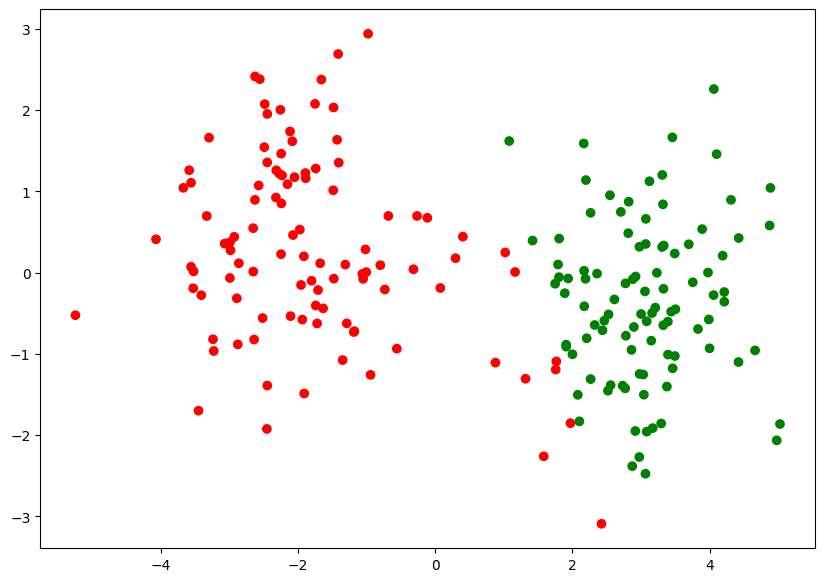

In [143]:
colors = ("red", "green")
colored_y = np.zeros(len(nn_prediction), dtype=str)

for i, cl in enumerate([0,1]):
    colored_y[nn_prediction.ravel() == cl] = str(colors[i])

plt.figure(figsize=(10,7))
plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y)
plt.show()

Покрасим все точки плоскости в цвета в зависимости от того, в какой класс наша сеть отнесла бы эти точки. Так мы лучше увидим разделяющую поверхность:

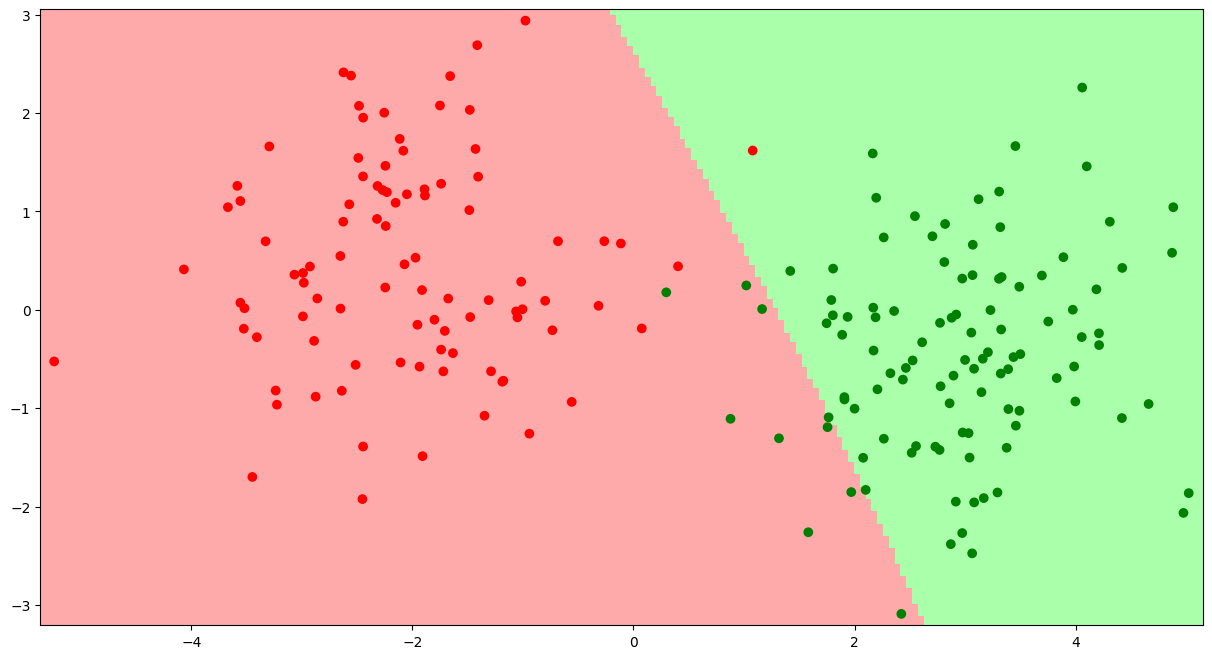

In [144]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15,8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X_test[:,0]) - eps, np.max(X_test[:,0]) + eps, 200),
                     np.linspace(np.min(X_test[:,1]) - eps, np.max(X_test[:,1]) + eps, 200))
Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape).detach().numpy()
Z = (Z>0.5).astype(int)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

colored_y = np.zeros(y_test.size, dtype=str)
for i, cl in enumerate([0,1]):
    colored_y[y_test.ravel() == cl] = str(colors[i])

plt.scatter(X_test[:, 0], X_test[:, 1], c=colored_y)

#### `nn.Sequential`


Давайте еще раз посмотрим на то, как мы задавали нашу нейросеть:

In [145]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc1 = nn.Linear(2, 2)
        self.act1 = nn.Sigmoid()

        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()


    def forward(self, x):

        x = self.fc1(x)
        x = self.act1(x)

        x = self.fc2(x)
        x = self.act2(x)
        return x

В PyTorch есть еще один способ задания структуры нейросети, через `nn.Sequential`. Выглядит это так:

In [146]:
model = nn.Sequential(
                   nn.Linear(2, 2, bias=True),
                   nn.Sigmoid(),
                   nn.Linear(2, 1, bias=True),
                   nn.Sigmoid()
                   )

Теперь с переменной model можно обращаться точно так же, как мы делали это выше. Эту сеть можно обучить и получать ответы на тестовых данных.

Этот способ создания сети выглядит проще (не нужно писать никакой класс и никакой `forward`), но он менее гибок. Дело в том, что, используя `nn.Sequential`, мы задаем только слои сети, и выполняться они будут при вызове сети ровно в том порядке, в котором мы их задали. Отсюда и название структуры `Sequential` — "последовательный". В случае же описания сети в виде класса мы могли в forward определять вид прохождения входа по сети сами. Например, могли бы сделать такую нейросеть:

In [147]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc11 = nn.Linear(2, 2)
        self.act11 = nn.Sigmoid()

        self.fc12 = nn.Linear(2, 2)
        self.act12 = nn.Sigmoid()

        self.fc2 = nn.Linear(4, 1)
        self.act2 = nn.Sigmoid()


    def forward(self, x1, x2):

        x1 = self.fc11(x1)
        x1 = self.act11(x1)

        x2 = self.fc12(x2)
        x2 = self.act12(x2)

        x = torch.cat([x1, x2], dim=1)

        x = self.fc2(x)
        x = self.act2(x)
        return x

Или можно делать даже так:

In [148]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.fc11 = nn.Linear(2, 2)
        self.act11 = nn.Sigmoid()

        self.fc12 = nn.Linear(2, 2)
        self.act12 = nn.Sigmoid()

        self.fc2 = nn.Linear(2, 1)
        self.act2 = nn.Sigmoid()


    def forward(self, x, mode='left'):

        if mode == 'left':
            x = self.fc11(x)
            x = self.act11(x)

        elif mode == 'right':
            x = self.fc12(x2)
            x = self.act12(x2)

        x = self.fc2(x)
        x = self.act2(x)
        return x

Таким образом, при задании сети в виде класса у нас есть бОльшая гибкость в определении того, как сеть будет обрабатывать входные данные на каждой новой итерации.

Но, несмотря на это, nn.Sequential все-таки используется при создании сетей. Он часто используется внутри метода init, чтобы сгруппировать несколько слоев сети в блок. Например, вот так:

In [149]:
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.left_block = nn.Sequential(
            nn.Linear(2, 2),
            nn.Sigmoid()
        )

        self.right_block = nn.Sequential(
            nn.Linear(2, 2),
            nn.Sigmoid()
        )

        self.bottom_block = nn.Sequential(
            nn.Linear(2, 2),
            nn.Sigmoid()
        )


    def forward(self, x, mode='left'):

        if mode == 'left':
            x = self.left_block(x)

        elif mode == 'right':
            x = self.right_block(x)

        x = self.bottom_block(x)
        return x